In [1]:
import os
import glob
import sys

import itertools

import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm as tqdm_auto
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import pytorch_lightning as pl

from IPython.display import clear_output

In [2]:
# Load all models
sys.path.append("../model-collection/")
# from optimus5 import Optimus5PrimeOriginal
from optimus5_25 import Optimus5Prime25
# from mttrans import RL_gru
# from framepool import FramePool
from dream_wrappers import DreamRNNFacade, DreamAttnFacade

In [3]:
sys.path.append("../../predictor/model/")
import stability_data as stability_data
from pl_regressor import RNARegressor
from legnet_classifier import LegNetClassifier

In [4]:
utr_type = "stability"
seqsize = 186

## Loading data

In [5]:
PATH_FROM = f"../../predictor/regression_stability/ratios_log_stability.csv"
df = pd.read_csv(PATH_FROM)

In [6]:
Y_NAME = "log_ratio"

In [7]:
splits = dict(tuple(df.groupby('fold')))
for split_df in splits.values():
    split_df.reset_index(drop=True, inplace=True)
splits["test"].head()

,seq,fold,log_ratio
0,AAAAAGTAGGCGCCAATCCCCAGCACCTCTCCTCCTACTCAATTCT...,test,-0.636069
1,AAAAGGAAAACCGGAGGAGCAATTGGGGATCCAGGTGTCAGAGGTA...,test,-0.893226
2,AAACCCTTGGTGGCTGCTCAAGACAGTTCCCCTCCTAAAATCACAC...,test,-0.874148
3,AAAGAGCACATGGGAGCCTCCAGATGGTCCCAGTTGAGTACTGCTG...,test,-0.621287
4,AAAGCCAAAATATAGAACAAACACCCCACCTGCGCTATGCCAGTAA...,test,-0.752849


In [8]:
batch_size = 128

In [9]:
num_workers = 32

In [10]:
test_set = stability_data.StabilityData(
    df=splits["test"],
    predict_cols=[Y_NAME],
    features=("sequence",),
)
dl_test = DataLoader(
    test_set,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    drop_last=False
)

### Loading models

In [11]:
legnet_checkpoint = glob.glob(f"../../predictor/regression_stability/saved_models/stability-epoch=24-step=725.ckpt")[0]
# legnet_checkpoint = glob.glob(f"../../predictor/regression_stability/saved_models/stability-epoch=24-step=725.ckpt")[0]
model_checkpoints = {os.path.basename(os.path.dirname(path)): path for path in glob.glob(f"./saved_models/{utr_type}/*/*.ckpt")}
model_checkpoints

{'DreamAttnFacade': './saved_models/stability/DreamAttnFacade/epoch=4-step=585.ckpt',
 'DreamRNNFacade': './saved_models/stability/DreamRNNFacade/epoch=18-step=2223.ckpt',
 'Optimus5Prime25': './saved_models/stability/Optimus5Prime25/epoch=49-step=1450.ckpt'}

In [12]:
models = dict()
for model_name, ckpt_path in model_checkpoints.items():
    ckpt = torch.load(ckpt_path)
    loaded_model = RNARegressor(**ckpt["hyper_parameters"])
    loaded_model.load_state_dict(ckpt["state_dict"])
    models[model_name] = loaded_model
legnet_ckpt = torch.load(legnet_checkpoint)
legnet_model = RNARegressor(**legnet_ckpt["hyper_parameters"])
legnet_model.load_state_dict(legnet_ckpt["state_dict"])

<All keys matched successfully>

In [13]:
progressbar_callback = pl.callbacks.TQDMProgressBar(refresh_rate=0.5)
trainer = pl.Trainer(
    callbacks=[progressbar_callback],
    logger=False,
    accelerator="gpu",
    devices=[0],
    deterministic=True,
    num_sanity_val_steps=0,
)
result_df = splits["test"][["seq", Y_NAME]].copy()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [14]:
for model_name, model_instance in models.items():
    print(model_name)
    prediction = trainer.predict(model=model_instance, dataloaders=dl_test)
    test_pred, test_real = zip(*prediction)
    test_pred = torch.concat(test_pred).numpy()
    # test_real = torch.concat(test_real).numpy()
    result_df[model_name] = test_pred[:, 0]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


DreamAttnFacade


Predicting: 0it [00:00, ?it/s]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


DreamRNNFacade


Predicting: 0it [00:00, ?it/s]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Optimus5Prime25


Predicting: 0it [00:00, ?it/s]

In [15]:
print("LegNetClassifier")
prediction = trainer.predict(model=legnet_model, dataloaders=dl_test)
test_pred, test_real = zip(*prediction)
test_pred = torch.concat(test_pred).numpy()
# test_real = torch.concat(test_real).numpy()
result_df["LegNetClassifier"] = test_pred[:, 0]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


LegNetClassifier


Predicting: 0it [00:00, ?it/s]

In [16]:
result_df_r = pd.concat({"pred_mass_center": result_df.drop(["seq", Y_NAME], axis=1)}, axis=1)
for i, col in enumerate(["seq", Y_NAME]):
    result_df_r.insert(i, col, result_df[col])
result_df_r

seq log_ratio  \
                                                                   
0    AAAAAGTAGGCGCCAATCCCCAGCACCTCTCCTCCTACTCAATTCT... -0.636069   
1    AAAAGGAAAACCGGAGGAGCAATTGGGGATCCAGGTGTCAGAGGTA... -0.893226   
2    AAACCCTTGGTGGCTGCTCAAGACAGTTCCCCTCCTAAAATCACAC... -0.874148   
3    AAAGAGCACATGGGAGCCTCCAGATGGTCCCAGTTGAGTACTGCTG... -0.621287   
4    AAAGCCAAAATATAGAACAAACACCCCACCTGCGCTATGCCAGTAA... -0.752849   
..                                                 ...       ...   
475  TTTACCATTGGTGATAGGGTTTAATACTAAGGTTTATTTTGAGTTT... -1.166476   
476  TTTCTCACAGCCGGTATTTATTGTCTGCTCCTCTGTGCCAGGTGCT... -0.967992   
477  TTTCTGTTTCCAGTCCAGTTACGGACTTCCCGGCCGCCACTGGGCC... -1.018240   
478  TTTTCTGTCACCCCAGTATCGCTGCACCCGGCCCCCCTCTCAGGCC... -1.053818   
479  TTTTTCTGCGCTTCAGTAACAAGTGTTGGCAAACGAGACTTTCTCC... -1.297885   

    pred_mass_center                                                  
     DreamAttnFacade DreamRNNFacade Optimus5Prime25 LegNetClassifier  
0          -0.745613      -0.785288       -0.706305        -0.812982  
1          -0.788234      -0.837496       -0.730339        -0.847088  
2          -0.817253      -0.843061       -0.743709        -0.798778  
3          -0.780452      -0.759593       -0.706479        -0.731056  
4          -0.800707      -0.781958       -0.709343        -0.723841  
..               ...            ...             ...              ...  
475        -1.019593      -1.019938       -0.902527        -1.109901  
476        -0.897860      -1.025811       -0.909031        -1.035220  
477        -0.822156      -1.076308       -0.874081        -1.001393  
478        -0.838039      -1.087274       -0.899145        -1.031154  
479        -0.870528      -1.139562       -0.948176        -1.051022  

[480 rows x 6 columns]

In [17]:
result_df_r.to_parquet(f"benchmark_preds_{utr_type}.parquet")

In [18]:
correlations = result_df[[Y_NAME] + list(models.keys()) + ["LegNetClassifier"]].corr()[Y_NAME].drop(Y_NAME)
correlations

DreamAttnFacade     0.471048
DreamRNNFacade      0.603247
Optimus5Prime25     0.574387
LegNetClassifier    0.581688
Name: log_ratio, dtype: float64

In [19]:
result_df[[Y_NAME] + list(models.keys()) + ["LegNetClassifier"]].corr(method='spearman')[Y_NAME].drop(Y_NAME)

DreamAttnFacade     0.465639
DreamRNNFacade      0.590737
Optimus5Prime25     0.547520
LegNetClassifier    0.564268
Name: log_ratio, dtype: float64

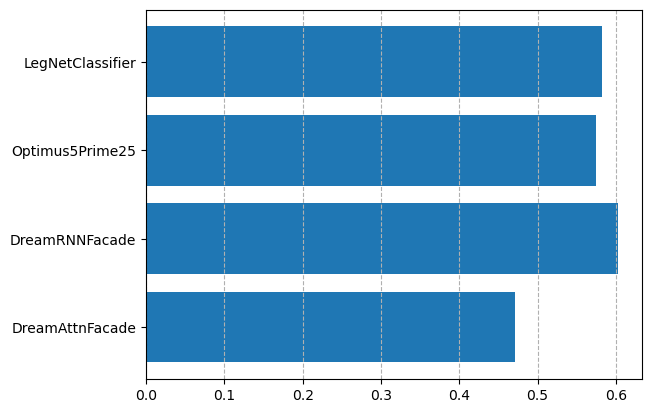

In [20]:
plt.barh(correlations.index, correlations)
plt.grid(axis='x', ls='--')

---